<a href="https://colab.research.google.com/github/Noorumms/MNIST-Digit-Classification-Using-Handcrafted-Features/blob/main/MNIST_Digit_Classification_Using_Handcrafted_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Project
## FOSF Feature Extraction + Random Forest Classification on MNIST


In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")


 All libraries imported successfully!


## Load MNIST Dataset

In [ ]:
# Load MNIST from OpenML (built into sklearn)

print("Loading MNIST dataset...")

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_full = mnist.data.astype(np.float64)
y_full = mnist.target.astype(int)

# Used 5000 samples to keep training fast
np.random.seed(42)
idx = np.random.choice(len(X_full), 5000, replace=False)
X_raw = X_full[idx]
y_raw = y_full[idx]

print(f"   Dataset loaded!")
print(f"   Total samples used : {X_raw.shape[0]}")
print(f"   Pixels per image   : {X_raw.shape[1]}  (28 x 28)")
print(f"   Classes            : {np.unique(y_raw)}")


Loading MNIST dataset...
   Dataset loaded!
   Total samples used : 5000
   Pixels per image   : 784  (28 x 28)
   Classes            : [0 1 2 3 4 5 6 7 8 9]


##  Visualise Sample Images

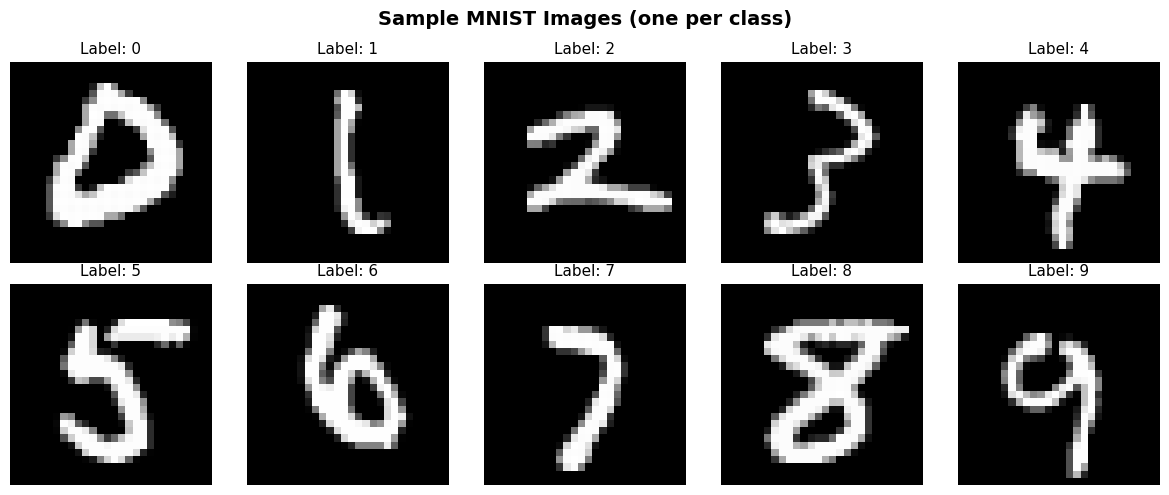

  Sample images visualised


In [ ]:
# Show one sample image for each digit class (0-9)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample MNIST Images (one per class)", fontsize=14, fontweight='bold')

for digit in range(10):
    ax = axes[digit // 5][digit % 5]
    sample_idx = np.where(y_raw == digit)[0][0]
    img = X_raw[sample_idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {digit}", fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Sample images visualised")


## FOSF Feature Extraction



In [ ]:
FEATURE_NAMES = [
    "Mean", "Median", "Variance", "Std Deviation",
    "Skewness", "Kurtosis", "Entropy",
    "Min Intensity", "Max Intensity", "Median Abs Deviation",
    "Local Contrast", "Local Probability",
    "25th Percentile", "75th Percentile"
]

def extract_features(pixel_array):
    p = list(pixel_array)
    N = len(p)


    mean = sum(p) / N


    p_sorted = sorted(p)
    if N % 2 == 1:
        median = p_sorted[N // 2]
    else:
        median = (p_sorted[N // 2 - 1] + p_sorted[N // 2]) / 2.0


    variance = sum((xi - mean) ** 2 for xi in p) / N


    std_dev = variance ** 0.5


    skewness = (sum((xi - mean) ** 3 for xi in p) / N) / (std_dev ** 3 + 1e-9)


    kurtosis = (sum((xi - mean) ** 4 for xi in p) / N) / (std_dev ** 4 + 1e-9) - 3


    hist = [0] * 256
    for xi in p:
        hist[min(int(xi), 255)] += 1
    entropy = 0.0
    for h in hist:
        if h > 0:
            prob = h / N
            entropy -= prob * math.log2(prob)


    min_int = p[0]
    for xi in p:
        if xi < min_int:
            min_int = xi


    max_int = p[0]
    for xi in p:
        if xi > max_int:
            max_int = xi


    abs_devs = sorted(abs(xi - median) for xi in p)
    M = len(abs_devs)
    if M % 2 == 1:
        mad = abs_devs[M // 2]
    else:
        mad = (abs_devs[M // 2 - 1] + abs_devs[M // 2]) / 2.0


    local_contrast = (max_int - min_int) / (max_int + min_int + 1e-9)


    local_prob = sum(1 for xi in p if xi > mean) / N


    def percentile(sorted_arr, q):
        pos = (q / 100.0) * (N - 1)
        lo = int(pos)
        hi = lo + 1
        frac = pos - lo
        if hi >= N:
            return sorted_arr[-1]
        return sorted_arr[lo] + frac * (sorted_arr[hi] - sorted_arr[lo])

    pct_25 = percentile(p_sorted, 25)
    pct_75 = percentile(p_sorted, 75)

    return [mean, median, variance, std_dev, skewness, kurtosis,
            entropy, min_int, max_int, mad,
            local_contrast, local_prob, pct_25, pct_75]

print("  feature extraction function defined!")

  feature extraction function defined!


## Build Feature Matrix

In [ ]:
# Apply feature extraction to every image
print("Extracting features from all images...")
X_features = np.array([extract_features(row) for row in X_raw])

print(f" Feature extraction complete!")
print(f"   Feature matrix shape : {X_features.shape}")
print(f"   ({X_features.shape[0]} images  x  {X_features.shape[1]} features)")


Extracting features from all images...
 Feature extraction complete!
   Feature matrix shape : (5000, 14)
   (5000 images  x  14 features)


## All Feature Values (First 10 Images)

In [ ]:
# Displaying feature values for first 10 images
df_features = pd.DataFrame(X_features, columns=FEATURE_NAMES)
df_features.insert(0, 'True Label', y_raw)

print("Feature values for the first 10 images:")
print("=" * 120)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
display(df_features.head(10))


Feature values for the first 10 images:


,True Label,Mean,Median,Variance,Std Deviation,Skewness,Kurtosis,Entropy,Min Intensity,Max Intensity,Median Abs Deviation,Local Contrast,Local Probability,25th Percentile,75th Percentile
0,8,58.7436,0.0000,9623.2085,98.0980,1.2401,-0.2910,2.4430,0.0000,255.0000,0.0000,1.0000,0.2640,0.0000,106.2500
1,4,35.8342,0.0000,6561.2659,81.0016,2.0263,2.3789,1.6633,0.0000,255.0000,0.0000,1.0000,0.1811,0.0000,0.0000
2,8,34.9923,0.0000,6115.5841,78.2022,2.0526,2.5472,2.0095,0.0000,254.0000,0.0000,1.0000,0.1875,0.0000,0.0000
3,7,25.3278,0.0000,5008.2152,70.7687,2.6658,5.4034,1.2001,0.0000,255.0000,0.0000,1.0000,0.1314,0.0000,0.0000
4,7,31.2296,0.0000,5987.1208,77.3765,2.2889,3.5185,1.4435,0.0000,255.0000,0.0000,1.0000,0.1594,0.0000,0.0000
5,0,55.8967,0.0000,9629.2763,98.1289,1.3338,-0.0539,1.8240,0.0000,255.0000,0.0000,1.0000,0.2691,0.0000,83.0000
6,6,39.9107,0.0000,7289.0839,85.3761,1.8721,1.7320,1.8505,0.0000,255.0000,0.0000,1.0000,0.1901,0.0000,0.0000
7,2,34.1658,0.0000,6238.7429,78.9857,2.0981,2.7141,1.6496,0.0000,255.0000,0.0000,1.0000,0.1760,0.0000,0.0000
8,7,22.5434,0.0000,4340.0491,65.8790,2.8388,6.5103,1.1082,0.0000,255.0000,0.0000,1.0000,0.1199,0.0000,0.0000
9,4,29.9222,0.0000,5461.6126,73.9027,2.3450,3.8832,1.6093,0.0000,255.0000,0.0000,1.0000,0.1582,0.0000,0.0000


## Feature Vectors

In [ ]:
# Show the complete feature vector for first 5 images
for i in range(5):
    print(f"\n{'='*65}")
    print(f"  Feature Vector — Image #{i}   (True Label: {y_raw[i]})")
    print(f"{'='*65}")
    print(f"  {'Feature':<25}  {'Value':>10}")
    print(f"  {'-'*38}")
    for j, name in enumerate(FEATURE_NAMES):
        print(f"  {name:<25}  {X_features[i, j]:>10.4f}")
    print(f"  {'-'*38}")
    fv = X_features[i]
    fv_str = "[" + ", ".join(f"{v:.3f}" for v in fv) + "]"
    print(f"  Vector: {fv_str}")



  Feature Vector — Image #0   (True Label: 8)
  Feature                         Value
  --------------------------------------
  Mean                          58.7436
  Median                         0.0000
  Variance                    9623.2085
  Std Deviation                 98.0980
  Skewness                       1.2401
  Kurtosis                      -0.2910
  Entropy                        2.4430
  Min Intensity                  0.0000
  Max Intensity                255.0000
  Median Abs Deviation           0.0000
  Local Contrast                 1.0000
  Local Probability              0.2640
  25th Percentile                0.0000
  75th Percentile              106.2500
  --------------------------------------
  Vector: [58.744, 0.000, 9623.209, 98.098, 1.240, -0.291, 2.443, 0.000, 255.000, 0.000, 1.000, 0.264, 0.000, 106.250]

  Feature Vector — Image #1   (True Label: 4)
  Feature                         Value
  --------------------------------------
  Mean                  

## Feature Vector Visualisation

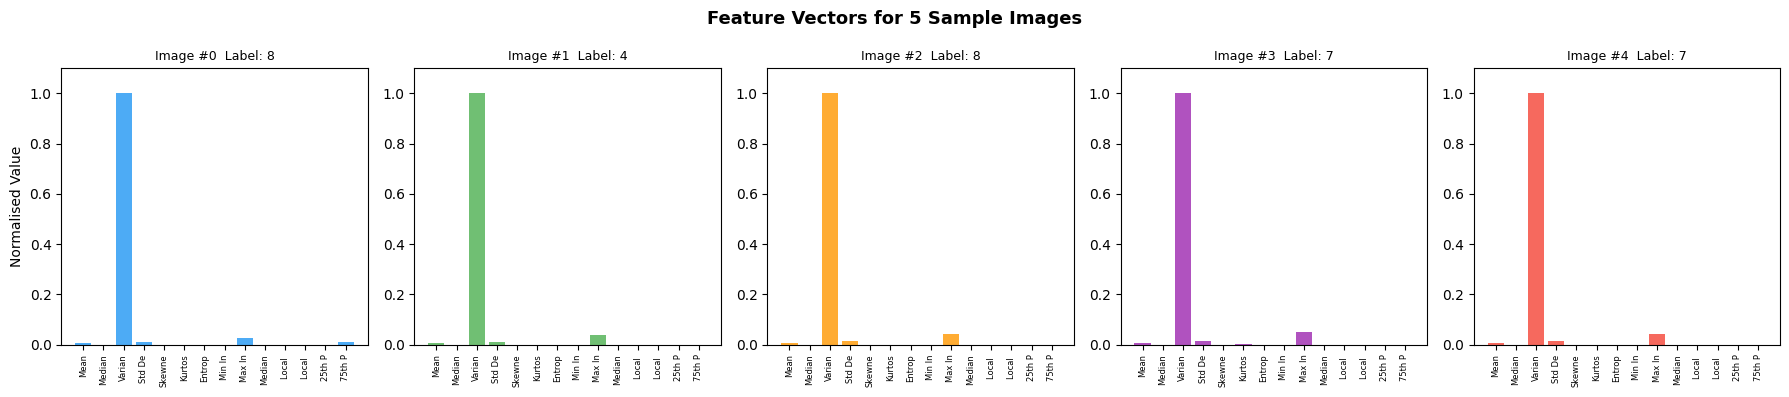

 Feature vectors visualised


In [ ]:
# Visualise feature vectors as bar charts for 5 images
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Feature Vectors for 5 Sample Images", fontsize=13, fontweight='bold')

colors_list = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
x = np.arange(len(FEATURE_NAMES))

for i, ax in enumerate(axes):
    fv = X_features[i]

    # Normalise for display (min-max)
    fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
    ax.bar(x, fv_norm, color=colors_list[i], alpha=0.8)
    ax.set_title(f"Image #{i}  Label: {y_raw[i]}", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([n[:6] for n in FEATURE_NAMES], rotation=90, fontsize=6)
    ax.set_ylabel("Normalised Value" if i == 0 else "")
    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('feature_vectors.png', dpi=120, bbox_inches='tight')
plt.show()
print(" Feature vectors visualised")


## Train / Test Split

In [ ]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

print(f"   Data split complete!")
print(f"   Training samples : {len(X_train)}")
print(f"   Testing  samples : {len(X_test)}")
print(f"   Feature vector size : {X_train.shape[1]}")


   Data split complete!
   Training samples : 4000
   Testing  samples : 1000
   Feature vector size : 14


## Random Forest Classifier



In [ ]:
# Train Random Forest

print("Training Random Forest Classifier...")

clf = RandomForestClassifier(
    n_estimators = 100,     # number of trees
    criterion    = 'gini',
    max_features = 'sqrt',
    random_state = 42,
    n_jobs       = -1
)

clf.fit(X_train, y_train)

print("    Model trained!")
print(f"   Trees in forest  : {clf.n_estimators}")
print(f"   Classes          : {clf.classes_}")


Training Random Forest Classifier...
    Model trained!
   Trees in forest  : 100
   Classes          : [0 1 2 3 4 5 6 7 8 9]


## Predict on Test Set

In [ ]:

y_pred = clf.predict(X_test)

# Show first 20 predictions vs actual labels
print("First 20 predictions vs actual labels:")
print(f"{'Index':<8} {'Actual':<10} {'Predicted':<12} {'Correct?'}")
print("-" * 42)
for i in range(20):
    correct = "Yes" if y_test[i] == y_pred[i] else "No"
    print(f"{i:<8} {y_test[i]:<10} {y_pred[i]:<12} {correct}")


First 20 predictions vs actual labels:
Index    Actual     Predicted    Correct?
------------------------------------------
0        3          2            No
1        9          3            No
2        0          0            Yes
3        0          0            Yes
4        5          0            No
5        1          1            Yes
6        7          0            No
7        5          9            No
8        2          6            No
9        6          3            No
10       0          0            Yes
11       5          4            No
12       6          0            No
13       7          7            Yes
14       1          1            Yes
15       4          4            Yes
16       2          4            No
17       6          9            No
18       0          5            No
19       2          3            No



##  Classification Results

In [ ]:

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

# Print summary
print("=" * 50)
print("       CLASSIFICATION RESULTS SUMMARY")
print("=" * 50)
print(f"  ACCURACY   :  {accuracy*100:.2f}%")
print(f"  PRECISION  :  {precision*100:.2f}%")
print(f"  RECALL     :  {recall*100:.2f}%")
print(f"  F1-SCORE   :  {f1*100:.2f}%")
print("=" * 50)
print()



       CLASSIFICATION RESULTS SUMMARY
  ACCURACY   :  25.60%
  PRECISION  :  24.21%
  RECALL     :  25.60%
  F1-SCORE   :  24.82%



##  Per-Class Classification Report

In [ ]:
# Detailed per-class breakdown
print("Per-Class Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred,
                             target_names=[f"Digit {i}" for i in range(10)]))


Per-Class Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.29      0.34      0.31        98
     Digit 1       0.80      0.90      0.85       110
     Digit 2       0.20      0.18      0.19        97
     Digit 3       0.13      0.13      0.13       111
     Digit 4       0.13      0.13      0.13        87
     Digit 5       0.11      0.09      0.10        95
     Digit 6       0.06      0.05      0.06        98
     Digit 7       0.24      0.27      0.25       103
     Digit 8       0.22      0.21      0.22        98
     Digit 9       0.17      0.18      0.18       103

    accuracy                           0.26      1000
   macro avg       0.24      0.25      0.24      1000
weighted avg       0.24      0.26      0.25      1000



## Confusion Matrix

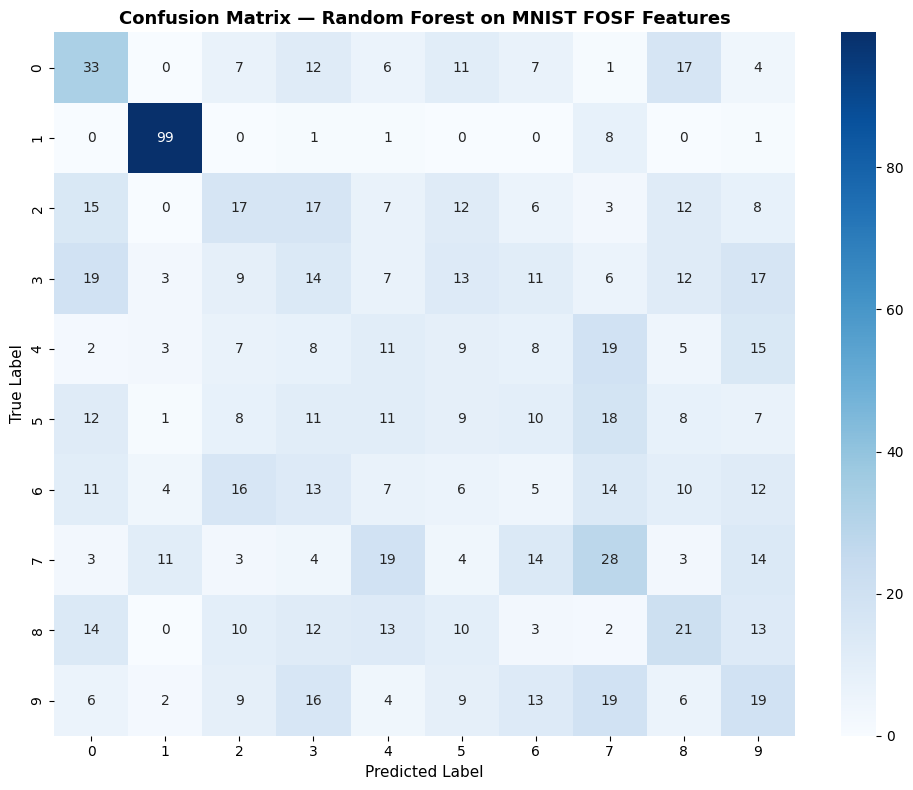

  Confusion matrix plotted


In [ ]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.title('Confusion Matrix — Random Forest on MNIST FOSF Features',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Confusion matrix plotted")


## Feature Importance

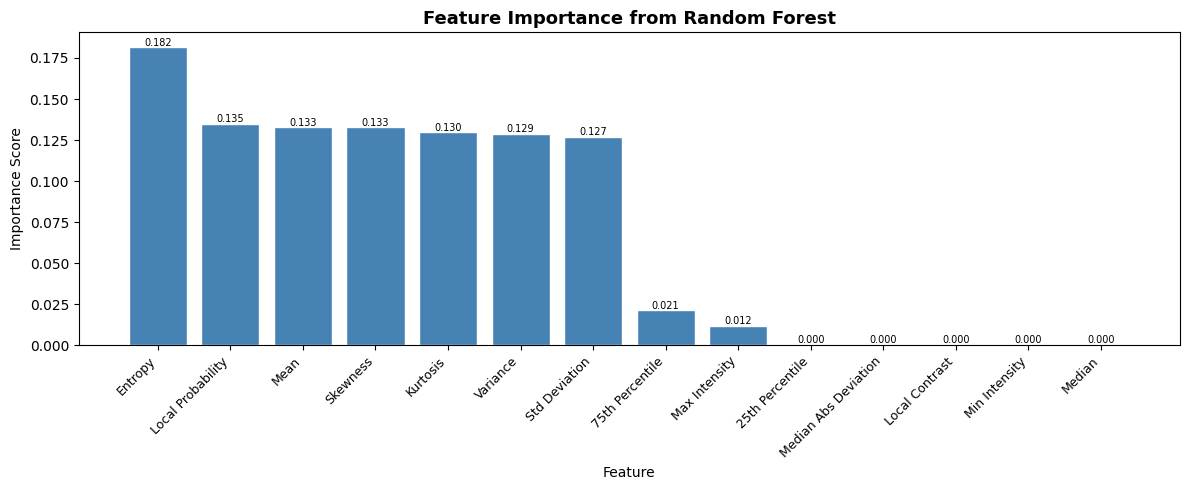


Feature Importance Ranking:
Rank   Feature                   Importance
------------------------------------------
1      Entropy                   0.1816
2      Local Probability         0.1347
3      Mean                      0.1327
4      Skewness                  0.1326
5      Kurtosis                  0.1296
6      Variance                  0.1289
7      Std Deviation             0.1271
8      75th Percentile           0.0212
9      Max Intensity             0.0116
10     25th Percentile           0.0000
11     Median Abs Deviation      0.0000
12     Local Contrast            0.0000
13     Min Intensity             0.0000
14     Median                    0.0000


In [ ]:

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 5))
bars = plt.bar(range(len(FEATURE_NAMES)),
               importances[indices],
               color='steelblue', edgecolor='white')
plt.xticks(range(len(FEATURE_NAMES)),
           [FEATURE_NAMES[i] for i in indices],
           rotation=45, ha='right', fontsize=9)
plt.title('Feature Importance from Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')

# Annotate bars
for bar, val in zip(bars, importances[indices]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{val:.3f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nFeature Importance Ranking:")
print(f"{'Rank':<6} {'Feature':<25} {'Importance'}")
print("-" * 42)
for rank, i in enumerate(indices, 1):
    print(f"{rank:<6} {FEATURE_NAMES[i]:<25} {importances[i]:.4f}")


## Step 16 — Results Summary Chart

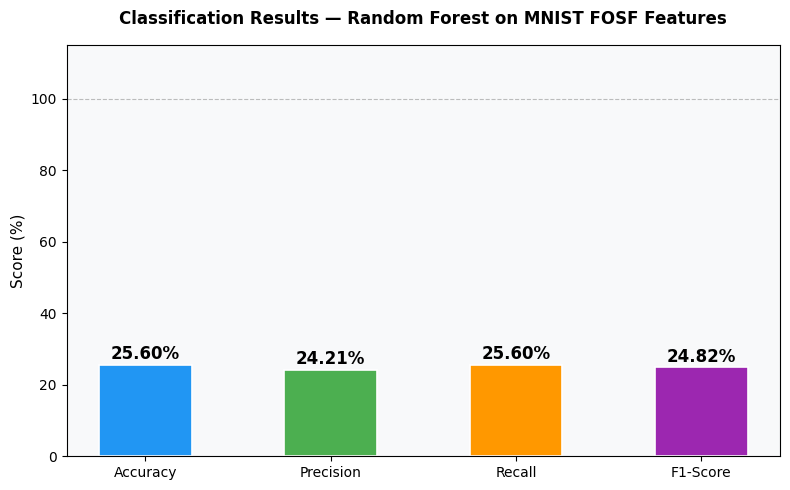


  Results:- 

   Accuracy  : 25.60%
   Precision : 24.21%
   Recall    : 25.60%
   F1-Score  : 24.82%


In [ ]:
# Final visual summary of the 4 metrics
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values      = [accuracy, precision, recall, f1]
bar_colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics, [v*100 for v in values],
              color=bar_colors, width=0.5, edgecolor='white', linewidth=1.2)

# Annotate
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val*100:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Classification Results — Random Forest on MNIST FOSF Features',
             fontsize=12, fontweight='bold', pad=15)
ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('results_summary.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n  Results:- \n")
print(f"   Accuracy  : {accuracy*100:.2f}%")
print(f"   Precision : {precision*100:.2f}%")
print(f"   Recall    : {recall*100:.2f}%")
print(f"   F1-Score  : {f1*100:.2f}%")
